# Load Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

import joblib

# Data Loading & Understanding

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/AI_ML/Datasets/House_Pricing.csv')

In [ ]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,...,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


In [ ]:
df.shape

(21613, 21)

In [ ]:
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [ ]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

# Detecting & handling duplicated rows

In [ ]:
df.duplicated().sum()
#No duplicated rows are identified

np.int64(0)

# Seperate X and y

In [ ]:
df=df.dropna(subset=['Sale Price'])
X=df.drop(columns=['Sale Price','ID'])
y=df['Sale Price']

In [ ]:
print(X.shape)
print(y.shape)

(21609, 19)
(21609,)


# Train-Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(17287, 19)
(4322, 19)
(17287,)
(4322,)


# Data Preprocessing


*   Detecting & Handling Missing value



In [ ]:
print('X_train:',X_train.isna().sum().sum())
print('X_test:',X_test.isna().sum().sum())
print('y_train:',y_train.isna().sum().sum())
print('y_test:',y_test.isna().sum().sum())

X_train: 15652
X_test: 3862
y_train: 0
y_test: 0


In [ ]:
num_col=X_train.select_dtypes(include='number').columns
cat_col=X_train.select_dtypes(include='object').columns


print('--------Numerical Missing Values-------')
print(X_train[num_col].isna().sum()[lambda x:x>0])

print('------Categorical Missing Values-------')
print(X_train[cat_col].isna().sum()[lambda x:x>0])

--------Numerical Missing Values-------
No of Bathrooms                              4
Flat Area (in Sqft)                          5
Lot Area (in Sqft)                           9
Area of the House from Basement (in Sqft)    2
Latitude                                     1
Longitude                                    1
Living Area after Renovation (in Sqft)       1
dtype: int64
------Categorical Missing Values-------
No of Times Visited    15629
dtype: int64


In [ ]:
X_train.drop(columns='No of Times Visited',inplace=True)
X_test.drop(columns='No of Times Visited',inplace=True)

### Imputation

In [ ]:
X_train_num=X_train.select_dtypes(include='number')
X_train_cat=X_train.select_dtypes(include='object')
X_test_num=X_test.select_dtypes(include='number')
X_test_cat=X_test.select_dtypes(include='object')

### Numerical Imputation

In [ ]:
imputer_num=SimpleImputer(strategy='median')

X_train_num_imputed=imputer_num.fit_transform(X_train_num)
X_test_num_imputed=imputer_num.transform(X_test_num)

In [ ]:
X_train_num_imputed=pd.DataFrame(X_train_num_imputed,
                                 columns=X_train_num.columns,
                                 index=X_train.index)
X_test_num_imputed=pd.DataFrame(
                                X_test_num_imputed,
                                columns=X_test_num.columns,
                                index=X_test.index
                              )

### Categorical Imputation

In [ ]:
imputer_cat=SimpleImputer(strategy='most_frequent')

X_train_cat_imputed=imputer_cat.fit_transform(X_train_cat)
X_test_cat_imputed=imputer_cat.transform(X_test_cat)

In [ ]:
X_train_cat_imputed=pd.DataFrame(X_train_cat_imputed,
                                 columns=X_train_cat.columns,
                                 index=X_train.index
                                 )
X_test_cat_imputed=pd.DataFrame(X_test_cat_imputed,
                                columns=X_test_cat.columns,
                                index=X_test.index
                                )

### Combine numerical & categorical cols

In [ ]:
X_train=pd.concat([X_train_num_imputed,X_train_cat_imputed],axis=1)
X_test=pd.concat([X_test_num_imputed,X_test_cat_imputed],axis=1)

### Verify

In [ ]:
print('X_train Missing Value:',X_train.isna().sum().sum())
print('X_test Missing Value:',X_test.isna().sum().sum())

X_train Missing Value: 0
X_test Missing Value: 0



# Detecting and Handling Outlier






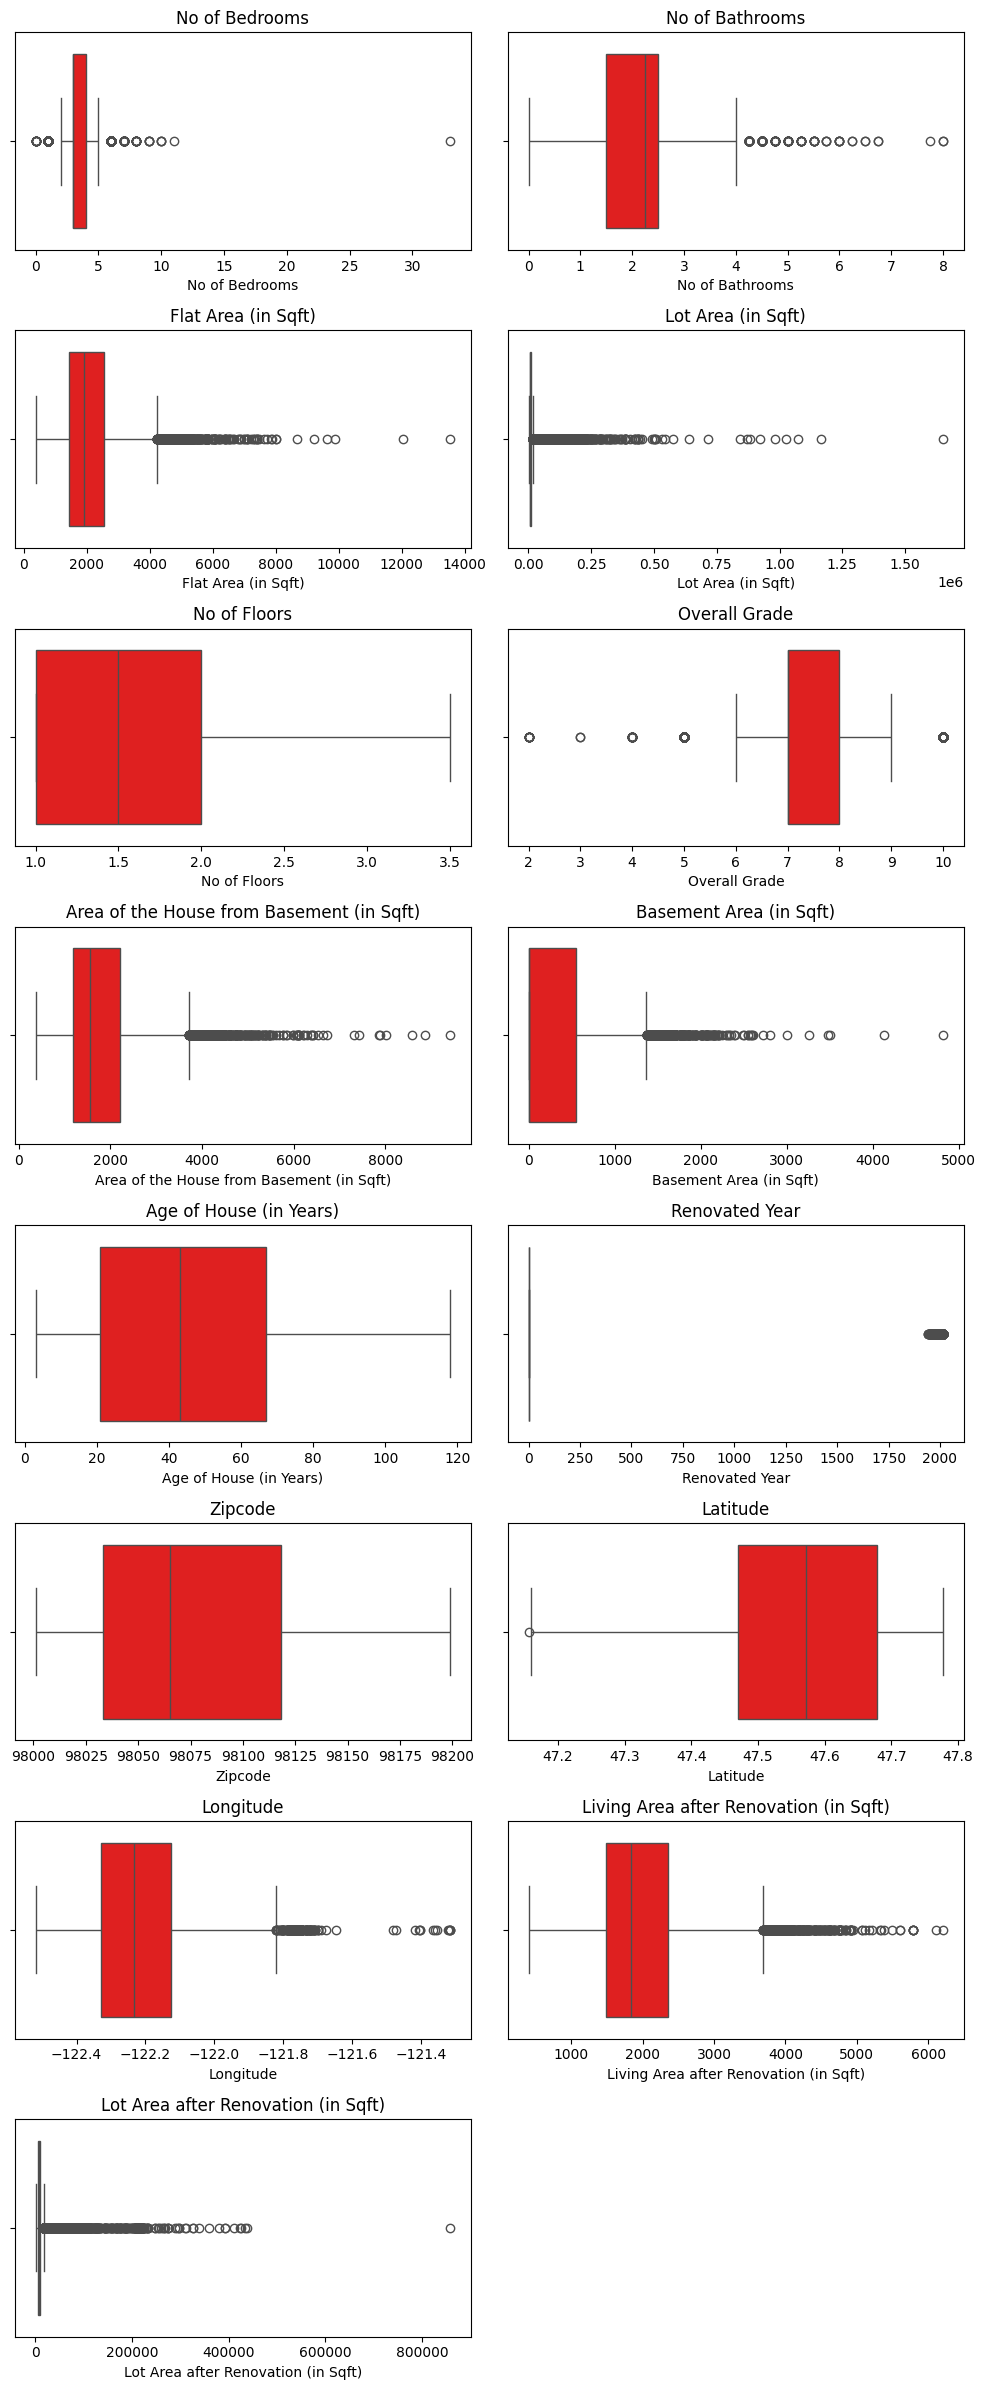

In [ ]:
X_train_num_col=X_train.select_dtypes(include='number').columns

rows=math.ceil(len(X_train_num_col)/2)
plt.figure(figsize=(10,rows*3))
for i,col in enumerate(X_train_num_col):
  plt.subplot(rows,2,i+1)
  sns.boxplot(x=X_train[col],color='red')
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
outlier_col=['Lot Area after Renovation (in Sqft)',
             'Living Area after Renovation (in Sqft)',
             'Basement Area (in Sqft)',
             'Area of the House from Basement (in Sqft)',
             'Flat Area (in Sqft)',
             'Lot Area (in Sqft)']

In [ ]:
def handle_outlier(col):
  Q1=X_train[col].quantile(0.25)
  Q3=X_train[col].quantile(0.75)
  IQR=Q3-Q1

  upper_b=Q3+1.5*IQR
  lower_b=Q1-1.5*IQR

  X_train[col]=X_train[col].clip(upper=upper_b,lower=lower_b)
  X_test[col]=X_test[col].clip(upper=upper_b,lower=lower_b)
for col in outlier_col :
  handle_outlier(col)

# Feature Extraction

In [ ]:
for data in [X_train,X_test]:
  data['Date House was Sold']=pd.to_datetime(data['Date House was Sold'])
  data['Sale_Month']=data['Date House was Sold'].dt.month
  data['Sale_Year']=data['Date House was Sold'].dt.year



In [ ]:
X_train.drop(columns='Date House was Sold',inplace=True)
X_test.drop(columns='Date House was Sold',inplace=True)


In [ ]:
print(X_train[['Sale_Month','Sale_Year']].head())
print(X_test[['Sale_Month','Sale_Year']].head())

       Sale_Month  Sale_Year
7095            5       2017
18538          10       2017
20023           6       2017
6254            7       2017
15383           7       2017
       Sale_Month  Sale_Year
4984            5       2016
10256           8       2017
4046           11       2017
21269           5       2017
10496           9       2017


# Encoding

In [ ]:
cat_col=X_train.select_dtypes(include='object').columns
for col in cat_col:
  print(f'----{col}:{X_train[col].nunique()}---')
  print(f'{X_train[col].unique()}')

----Waterfront View:2---
['No' 'Yes']
----Condition of the House:5---
['Good' 'Fair' 'Okay' 'Excellent' 'Bad']


In [ ]:
ordinal_order={
    'Waterfront View':['No', 'Yes'],
    'Condition of the House':['Bad','Okay','Fair','Good','Excellent']
}

ordinal_col=[c for c in ordinal_order if c in X_train.columns]

In [ ]:
ordinal=OrdinalEncoder(
    categories=[ordinal_order[c] for  c in ordinal_col],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)


In [ ]:
X_train_ord=pd.DataFrame(
    ordinal.fit_transform(X_train[ordinal_col]),
    columns=ordinal_col,
    index=X_train.index
)

X_test_ord=pd.DataFrame(
    ordinal.transform(X_test[ordinal_col]),
    columns=ordinal_col,
    index=X_test.index
)

In [ ]:
num_cols=X_train.select_dtypes(include='number').columns

X_train=pd.concat(
    [X_train[num_cols],X_train_ord],
    axis=1
)

X_test=pd.concat(
    [X_test[num_cols],X_test_ord],
    axis=1
)

In [ ]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


# Feature Selection

In [ ]:
train_data=X_train.copy()
train_data['Sale Price']=y_train

In [ ]:
corr=train_data.corr()

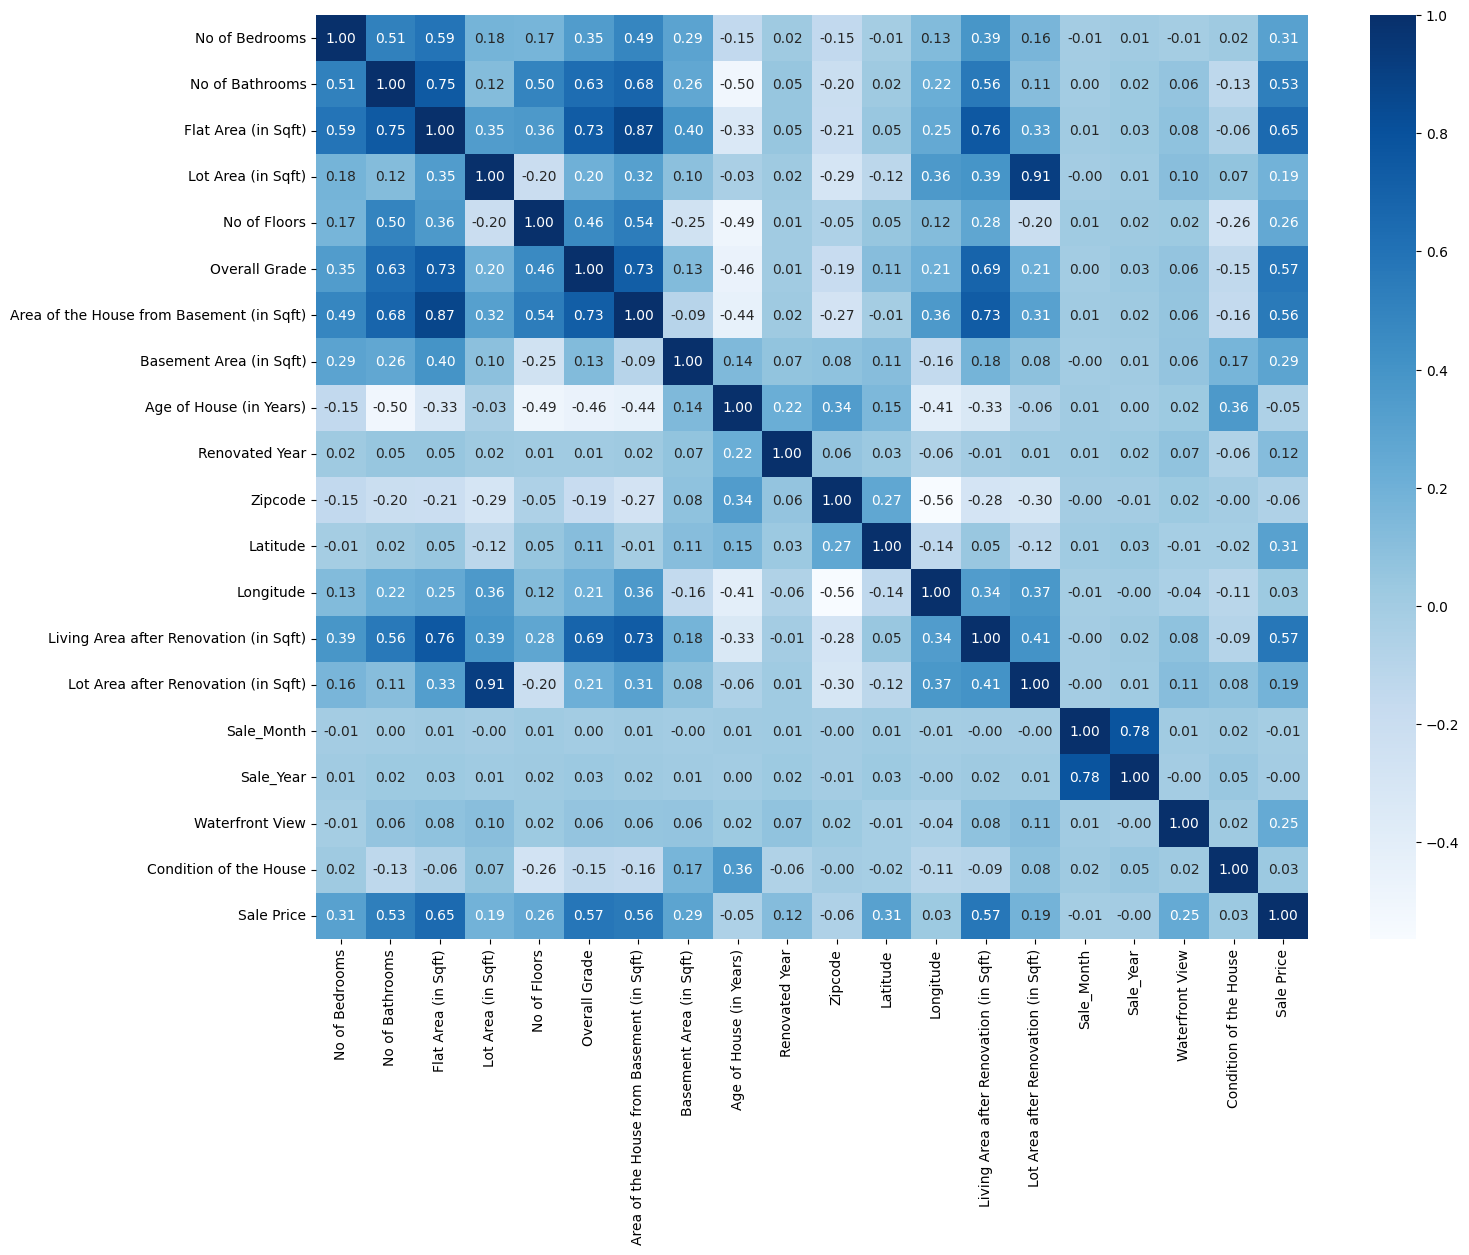

In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap(corr,annot=True,cmap='Blues',fmt='.2f')
plt.show()

In [ ]:
corr['Sale Price'].loc[lambda x:x.abs()>0.3]

,Sale Price
No of Bedrooms,0.307909
No of Bathrooms,0.527972
Flat Area (in Sqft),0.646444
Overall Grade,0.574269
Area of the House from Basement (in Sqft),0.558507
Latitude,0.307447
Living Area after Renovation (in Sqft),0.568600
Sale Price,1.000000


In [ ]:
sel_col=['Overall Grade',
         'No of Bedrooms',
         'Flat Area (in Sqft)',
         'No of Bathrooms',
         'Living Area after Renovation (in Sqft)',
         'Latitude']
X_train=X_train[sel_col]
X_test=X_test[sel_col]

# Feature Scaling

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Model Selection

In [ ]:
models={
    'LinearRegressor':LinearRegression(),
    'RandomForestRegressor':RandomForestRegressor(random_state=42),
    'DescisionTressRegressor':DecisionTreeRegressor(random_state=42),
    'KNN':KNeighborsRegressor()
    }

# Model Training

In [ ]:
for name,model in models.items():
  model.fit(X_train_scaled,y_train)
  print(f'{name} trained successfully!')

LinearRegressor trained successfully!
RandomForestRegressor trained successfully!
DescisionTressRegressor trained successfully!
KNN trained successfully!


# Model Prediction

In [ ]:
prediction={}

for name,model in models.items():
  prediction[name]=model.predict(X_test_scaled)

# Model Evaluation

In [ ]:
results = {}

for name, y_pred in prediction.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, mse, rmse, r2]



In [ ]:
results_df = pd.DataFrame(
    results,
    index=["MAE", "MSE", "RMSE", "R² Score"]
).T

results_df

,MAE,MSE,RMSE,R² Score
LinearRegressor,154504.856224,7.033529e+10,265208.019369,0.517701
RandomForestRegressor,101885.493709,4.342992e+10,208398.467393,0.702195
DescisionTressRegressor,138294.866960,7.670875e+10,276963.453256,0.473997
KNN,112384.855761,4.959341e+10,222695.774410,0.659931


# Save Model & Preprocessing objects

In [ ]:
rf_model = models['RandomForestRegressor']

joblib.dump(rf_model, "random_forest_model.pkl")

joblib.dump(imputer_num, "num_imputer.pkl")
joblib.dump(imputer_cat, "cat_imputer.pkl")
joblib.dump(ordinal, "ordinal_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(sel_col, "selected_features.pkl")

['selected_features.pkl']

# Load model & ppreprocessing objects

In [ ]:
rf_model = joblib.load("random_forest_model.pkl")

num_imputer = joblib.load("num_imputer.pkl")
cat_imputer = joblib.load("cat_imputer.pkl")
ordinal_encoder = joblib.load("ordinal_encoder.pkl")
scaler = joblib.load("scaler.pkl")

selected_features = joblib.load("selected_features.pkl")

# Prediction on new data

In [ ]:
new_data = {
    'Overall Grade': 8,
    'No of Bedrooms': 3,
    'Flat Area (in Sqft)': 1800,
    'No of Bathrooms': 2,
    'Living Area after Renovation (in Sqft)': 1700,
    'Latitude': 47.6
}

# Dictionary to DataFrame
new_data = pd.DataFrame([new_data])

# Same feature order  training
new_data = new_data[sel_col]

# Apply the already trained scaler
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = rf_model.predict(new_data_scaled)

print("Predicted Sale Price:", prediction[0])

Predicted Sale Price: 604851.0
